In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import classification_report, roc_curve, auc, ConfusionMatrixDisplay

In [52]:
df = pd.read_csv('heart.csv')

In [53]:
# limpiar nombres de columnas (evita errores invisibles)
df.columns = df.columns.str.strip()

# ver columnas
print(df.columns)

# ver primeras filas
df.head()

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [54]:
# usamos la última columna automáticamente
target_col = df.columns[-1]

X = df.drop(target_col, axis=1)
y = df[target_col]

print("Variable objetivo:", target_col)

Variable objetivo: target


In [55]:
print("X shape:", X.shape)
print("y shape:", y.shape)

assert len(X) == len(y)

X shape: (1025, 13)
y shape: (1025,)


In [56]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [57]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [59]:
knn = KNeighborsClassifier(n_neighbors=5)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(probability=True)

models = {
    "KNN": knn,
    "Random Forest": rf,
    "SVM": svm
}

In [60]:
for name, model in models.items():
    model.fit(X_train, y_train)

In [61]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))

    results.append({
        "Model": name,
        "Accuracy": model.score(X_test, y_test)
    })


KNN
              precision    recall  f1-score   support

           0       0.88      0.77      0.82       102
           1       0.80      0.89      0.84       103

    accuracy                           0.83       205
   macro avg       0.84      0.83      0.83       205
weighted avg       0.84      0.83      0.83       205


Random Forest
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205


SVM
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       102
           1       0.85      0.94      0.89       103

    accuracy                           0.89       205
   macro avg       0.89      0.89      0.89       205
weighted avg       0.89      0.89      0.89      

In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics_data = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    metrics_data.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

metrics_df = pd.DataFrame(metrics_data)

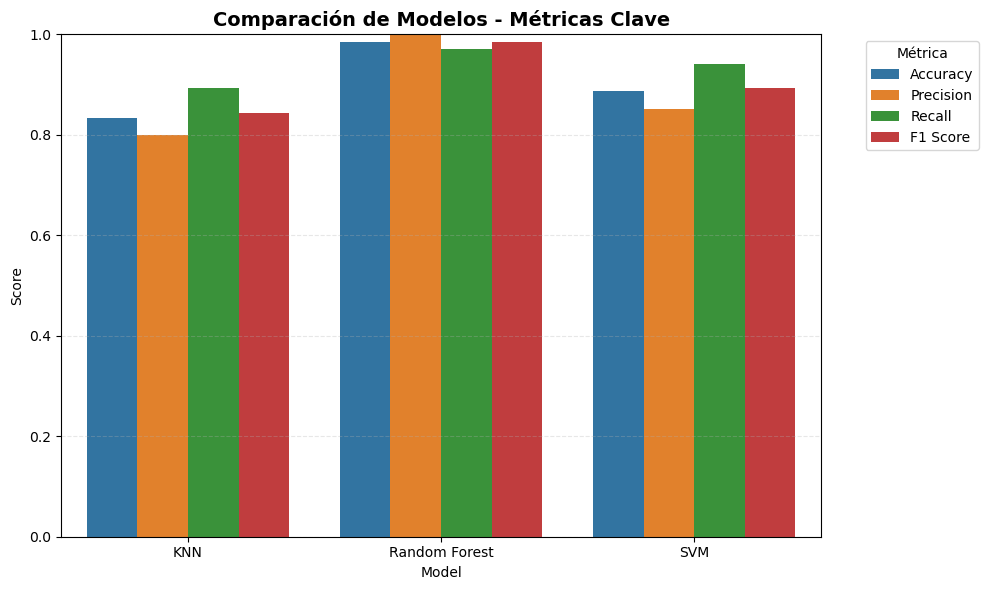

In [64]:
metrics_melted = metrics_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10,6))

sns.barplot(
    data=metrics_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Comparación de Modelos - Métricas Clave", fontsize=14, fontweight='bold')
plt.ylim(0,1)
plt.legend(title="Métrica", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()